<a href="https://colab.research.google.com/github/Jaguar838/stock-markets-analytics-zoomcamp/blob/main/cohorts/2026/hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Module 2 Homework](https://colab.research.google.com/github/Jaguar838/stock-markets-analytics-zoomcamp/blob/main/HW/2025/hw-02/hw-02.ipynb)

In [ ]:
# IMPORTS
import pandas as pd
import requests
from io import StringIO

#Fin Data Sources
import yfinance as yf

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import date, timedelta
from functools import wrap

### Question 1: [IPO] Withdrawn IPOs by Company Type

**What is the total withdrawn IPO value (in $ millions) for the company class with the highest total withdrawal value?**

From the Recently Filed IPO list ([iposcoop.com/ipos-recently-filed](https://www.iposcoop.com/ipos-recently-filed/)), collect and process the data to find out which company type saw the most withdrawn IPO value before Sep 11, 2026.

#### Steps:
1. **Data Loading:** Use `pandas.read_html()` with the URL above to load the IPO recently filed table. Filter the rows to keep only those where 'Expected To Trade' is 'Withdrawn'. You should identify 32 entries.
2. **Company Classification:** Create a new column called **Company Type**, categorizing company names based on patterns (order matters, assign the first matched value):
    - "Technologies" -> Technologies
    - "Acquisition Corp", "Acquisition Corporation", or "Corp" -> Acquisition Corp
    - "Inc" or "Incorporated" -> Inc.
    - "Group" -> Group
    - "Ltd" or "Limited" -> Limited
    - "Holdings" or "Holding" -> Holdings
    - Others -> Other

    **Note:** The order of the rules above is important — use the first matching rule. For example, "EUPEC International Group Ltd." will be classified as `Group` (not `Limited`), since the "Group" rule appears before the "Ltd"/"Limited" rule. Also, matches must be exact: "Xinxu Copper Industry Technology Ltd." will be classified as `Limited` (not `Technologies`), because "Technology" does not match the "Technologies" pattern.
3. **Price Parsing:** Define a new field **Avg_price** by parsing the 'Price Low' and 'Price High' fields. Create a function to extract numeric values (e.g., '$8.00' -> 8.0) and calculate the average between low and high. Handle '-' or missing values as `None`/`NaN`.
4. **Numeric Conversion:** Convert 'Shares (millions)' and 'Est \$ Vol (millions)' to numeric formats, cleaning currency symbols (\$) and commas where necessary.
5. **Value Calculation:** Create a new column **Shares_offered_value**:
    - If `Shares (millions) * Avg_price` is not null, use that value.
    - Otherwise, use the value from the `Est $ Vol (millions)` column.
6. **Aggregation:** Group by **Company Type** and calculate the sum of **Shares_offered_value**.

**Answer:** Which class had the highest total value of withdrawals, and what was that value?

---

### Question 1: [IPO] Withdrawn IPOs by Company Type

**Яка загальна сума виведених коштів з ІРО (у мільйонах доларів США) для класу компаній з найбільшою загальною сумою виведених коштів?**

Зі списку відкликаних IPO ([stockanalysis.com/ipos/withdrawn](https://stockanalysis.com/ipos/withdrawn/)) зберіть та обробіть дані, щоб з'ясувати, який тип компаній отримав найбільше відкликаних IPO.

Крок за кроком:
1. Використовуйте `pandas.read_html()` з наведеною вище URL-адресою, щоб завантажити таблицю виведення IPO в DataFrame.
   *Процес аналогічний до фрагменту коду 1, що обговорюється в прямому ефірі.* Ви маєте отримати **99 записів**.
2. Створіть новий стовпець під назвою `Company Class`, класифікуючи назви компаній за такими шаблонами, як:
   - "Acquisition Corp." або "Acquisition Corporation" → `Acq.Corp`.
   - "Inc." або "Incorporated" → `Inc`.
   - "Group" або "Group" → `Group`
   - "Ltd." або "Limited" → `Limited`, "Обмежений" → `Limited`.
   - "Holdings" → `Holdings`.
   - "Others" → `Other`.

  * Порядок: Будь ласка, дотримуйтесь переліченого порядку класів і присвоюйте перше знайдене значення (наприклад, для "shenni holdings limited" ви присвоюєте клас "Limited").

  * Підказка: зробіть вашу функцію більш надійною, перетворивши імена в малі літери та розбивши їх на слова перед тим, як порівнювати шаблони.

3. Визначте нове поле `Avg. Price` шляхом аналізу поля `Price Range` (створіть функцію і застосуйте її до стовпця `Price Range`).
  Приклади:
   - `$8.00 - $10.00` → `9.0`
   - `$5.00` → `5.0`
   - '-' → `None`

4. Перетворіть `Shares Offered` в числові, очистіть відсутні або недійсні значення.
5. Створіть новий стовпець:  
   `Withdrawn Value = Shares Offered * Avg Price` (**71 non-null values**)
6. Згрупуйте за "Класом компанії" та підрахуйте загальну вилучену вартість.
7. **Answer**: Який клас має найбільшу **total** вартість виведених коштів?
---

In [ ]:

def normalize_column_names(df):
    """
    Приводить назви колонок до нижнього регістру та замінює пробіли/дефіси на підкреслення.
    """
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
    return df


def clean_and_convert_column(df, column_name):
    """
    Очищає значення в зазначеній колонці DataFrame від небажаних символів
    і перетворює їх у числовий формат.
    """
    df = df.copy()  # додано для уникнення SettingWithCopyWarning
    df[column_name] = (
        df[column_name]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.strip()
    )
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    return df


def handle_errors(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
        except ValueError as ve:
            print(f"Data error: {ve}")
        except Exception as ex:
            print(f"Unexpected error: {ex}")
        return pd.DataFrame()
    return wrapper


In [ ]:
@handle_errors
def get_ipos(url: str) -> pd.DataFrame:
    """
    Завантажує IPO-таблицю з заданого URL (stockanalysis.com),
    нормалізує назви колонок, перетворює дати, сортує по даті.
    """
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/58.0.3029.110 Safari/537.3'
        )
    }

    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()

    html_io = StringIO(response.text)
    tables = pd.read_html(html_io)

    if not tables:
        raise ValueError("No tables found at provided URL.")

    df = tables[0]
    df = normalize_column_names(df)

    # Перетворення всіх колонок із "date" у назві в datetime
    for col in df.columns:
        if 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Сортуємо по першій колонці, яка є датою
    date_cols = [col for col in df.columns if 'date' in col]
    if date_cols:
        df = df.sort_values(by=date_cols[0], ascending=False)

    return df

In [ ]:
# Парсимо таблицю з IPO:
url = "https://www.iposcoop.com/ipos-recently-filed/"
df_withdrawn_ipos =get_ipos(url)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000
6,CABR,"Caring Brands, Inc.",$4.00,750000
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000
9,KMCM,Key Mining Corp.,$2.25,4444444


In [ ]:
df_withdrawn_ipos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   symbol          100 non-null    object
 1   company_name    100 non-null    object
 2   price_range     100 non-null    object
 3   shares_offered  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [ ]:
def classify_company(name):
    name = name.lower()
    words = name.split()

    if 'acquisition' in words and ('corp.' in words or 'corp' in words or 'corporation' in words):
        return 'Acq.Corp.'
    elif 'inc.' in words or 'incorporated' in words:
        return 'Inc.'
    elif 'group' in words:
        return 'Group'
    elif 'ltd.' in words or 'limited' in words:
        return 'Limited'
    elif 'holdings' in words:
        return 'Holdings'
    else:
        return 'Other'


# Застосовуємо функцію до кожного рядка
df_withdrawn_ipos['company_class'] = df_withdrawn_ipos.company_name.apply(classify_company)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc.
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc.
2,AURN,"Aurion Biotech, Inc.",-,-,Inc.
3,ROTR,"PHI Group, Inc.",-,-,Inc.
4,ONE,One Power Company,-,-,Other
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc.
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc.
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
9,KMCM,Key Mining Corp.,$2.25,4444444,Other


In [ ]:
def parse_avg_price(price_range):
    if not isinstance(price_range, str) or price_range.strip() == '-' or price_range.strip() == '':
        return None

    # Прибираємо символи долара і пробіли
    cleaned = price_range.replace('$', '').strip()

    # Розбиваємо за тире
    parts = cleaned.split('-')

    try:
        # Якщо два числа — беремо середнє
        if len(parts) == 2:
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return round((low + high) / 2, 2)
        # Якщо одне число — просто повертаємо
        elif len(parts) == 1:
            return round(float(parts[0].strip()), 2)
        else:
            return None
    except ValueError:
        return None


df_withdrawn_ipos['avg_price'] = df_withdrawn_ipos.price_range.apply(parse_avg_price)

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc.,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc.,3.50
2,AURN,"Aurion Biotech, Inc.",-,-,Inc.,NaN
3,ROTR,"PHI Group, Inc.",-,-,Inc.,NaN
4,ONE,One Power Company,-,-,Other,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited,5.00
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc.,4.00
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc.,9.00
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited,5.00
9,KMCM,Key Mining Corp.,$2.25,4444444,Other,2.25


In [ ]:
# Видалимо коми, пробіли, символи типу '$', і спробуємо перетворити в число
df_withdrawn_ipos = clean_and_convert_column(df_withdrawn_ipos, 'shares_offered')


df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc.,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc.,3.50
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc.,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc.,NaN
4,ONE,One Power Company,-,NaN,Other,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000.0,Limited,5.00
6,CABR,"Caring Brands, Inc.",$4.00,750000.0,Inc.,4.00
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000.0,Inc.,9.00
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000.0,Limited,5.00
9,KMCM,Key Mining Corp.,$2.25,4444444.0,Other,2.25


In [ ]:
df_withdrawn_ipos['withdrawn_value'] = df_withdrawn_ipos.shares_offered * df_withdrawn_ipos.avg_price

df_withdrawn_ipos.head(10)

,symbol,company_name,price_range,shares_offered,company_class,avg_price,withdrawn_value
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc.,NaN,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc.,3.50,7000000.0
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc.,NaN,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc.,NaN,NaN
4,ONE,One Power Company,-,NaN,Other,NaN,NaN
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000.0,Limited,5.00,7000000.0
6,CABR,"Caring Brands, Inc.",$4.00,750000.0,Inc.,4.00,3000000.0
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000.0,Inc.,9.00,24975000.0
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000.0,Limited,5.00,15000000.0
9,KMCM,Key Mining Corp.,$2.25,4444444.0,Other,2.25,9999999.0


In [ ]:
grouped_df = df_withdrawn_ipos.groupby('company_class')['withdrawn_value'].sum().sort_values(ascending=False)
len(grouped_df)

6

In [ ]:
grouped_df = grouped_df.reset_index()
grouped_df.columns = ['company_class', 'withdrawn_value']
grouped_df.head(6)


,company_class,withdrawn_value
0,Acq.Corp.,4.021000e+09
1,Inc.,2.257164e+09
2,Other,7.741700e+08
3,Limited,5.434846e+08
4,Holdings,7.500000e+07
5,Group,3.378750e+07


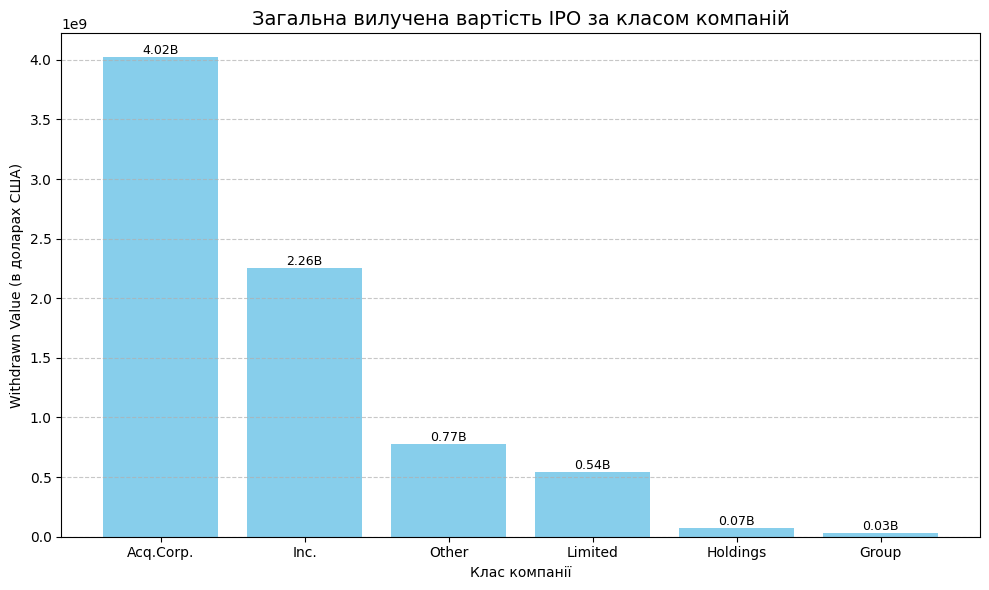

In [ ]:
# Побудова стовпчикової діаграми
plt.figure(figsize=(10, 6))
bars = plt.bar(grouped_df['company_class'], grouped_df['withdrawn_value'], color='skyblue')

# Підписи значень над стовпчиками
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height/1e9:.2f}B',
             ha='center', va='bottom', fontsize=9)

plt.title('Загальна вилучена вартість IPO за класом компаній', fontsize=14)
plt.xlabel('Клас компанії')
plt.ylabel('Withdrawn Value (в доларах США)')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(
    f'Answer: Клас компаній з найбільшою загальною вартістю виведених коштів — {grouped_df.company_class[0]}, із сумою ${grouped_df.withdrawn_value[0]/1e9:.2f} млрд.'
    )

Answer: Клас компаній з найбільшою загальною вартістю виведених коштів — Acq.Corp., із сумою $4.02 млрд.


### Question 2:   [IPO] Median Sharpe Ratio for 2024 IPOs (First 5 Months)

**Яким є медіанний коефіцієнт Шарпа (станом на 6 червня 2025 року) для компаній, які стали публічними за перші 5 місяців 2024 року?**

Мета полягає в тому, щоб відтворити великомасштабне завантаження даних "yfinance" OHLCV і виконати базові фінансові розрахунки щодо акцій IPO.

1. Використовуючи той самий підхід, що і в питанні 1, завантажте IPO у 2024 році з:
 [https://stockanalysis.com/ipos/2024/](https://stockanalysis.com/ipos/2024/)
 Відфільтруйте, щоб залишити лише ті IPO, які відбулися **до 1 червня 2024 року** (перші 5 місяців 2024 року).  
   У вас повинно бути **75 тикерів**.

2.  Використовуйте **Фрагмент коду 7**, щоб завантажити щоденні дані про запаси для цих тикерів (через `yfinance`).  
   Переконайтеся, що ви розумієте, як визначаються стовпці `growth_1d` ... `growth_365d` та стовпці волатильності.  
   Визначте новий стовпець `growth_252d`, що відображає зростання після **252 торгових днів** (~1 рік), на додаток до будь-яких інших періодів зростання, які ви вже відстежуєте.

3. Розрахуйте коефіцієнт Шарпа, припускаючи, що безризикова ставка становить **4.5%**:

   ```python
 stocks_df['Sharpe'] = (stocks_df['growth_252d'] - 0.045) / stocks_df['volatility']
 ```

   ⚠️ **IMPORTANT:**  Пожалуйста, используйте оригинальную версию расчета годовой волатильности (позже она была исправлена на другую формулу):

  ```python
 stocks_df['volatility'] = stocks_df['Close'].rolling(30).std() * np.sqrt(252)
 ```

4. Відфільтруйте DataFrame, щоб зберегти дані тільки за торговий день:
   **'2025-06-06'**

   Обчисліть описову статистику (наприклад, `.describe()`) для цих стовпців:
   - `growth_252d`
   - `Sharpe`

   Ви повинні спостерігати:
   - `growth_252d` визначено для **71 з 75 акцій** (деякі IPO є занадто пізніми або дані починаються пізніше).
   - Медіана `growth_252d` становить приблизно **0,75** (що вказує на 25% падіння), тоді як середнє значення становить приблизно **1.15**, що свідчить про те, що компанії, які швидко зростають, підштовхують середнє значення вгору.

5. **Answer:**
   - Який **середній коефіцієнт Шарпа** для цих 71 акцій?
   - Примітка: Позитивне значення показника Шарпа означає зростання, що перевищує безризикову ставку 4,5%.
   - [Additional] Чи спостерігаєте ви **однакові 10 найкращих компаній** при сортуванні за `growth_252d` та сортуванні за `Sharpe`?

In [ ]:
# Парсимо таблицю з IPO:
url = "https://stockanalysis.com/ipos/2024/"
df_2024_ipos =get_ipos(url)

df_2024_ipos.head(10)

,ipo_date,symbol,company_name,ipo_price,current,return
0,2024-12-31,ONEG,OneConstruction Group Limited,$4.00,$5.44,36.00%
1,2024-12-27,PHH,"Park Ha Biological Technology Co., Ltd.",$4.00,$30.11,652.75%
2,2024-12-23,HIT,"Health In Tech, Inc.",$4.00,$0.66,-83.45%
3,2024-12-23,TDAC,Translational Development Acquisition Corp.,$10.00,$10.27,2.70%
4,2024-12-20,RANG,Range Capital Acquisition Corp.,$10.00,$10.20,2.00%
5,2024-12-20,YAAS,Youxin Technology Ltd,$4.50,$2.86,-36.56%
6,2024-12-19,LSE,"Leishen Energy Holding Co., Ltd.",$4.00,$6.25,56.25%
7,2024-12-18,NCEW,New Century Logistics (BVI) Limited,$4.00,$0.93,-76.88%
8,2024-12-18,YSXT,"YSX Tech. Co., Ltd",$4.00,$5.67,41.75%
9,2024-12-13,AVR,Anteris Technologies Global Corp.,$6.00,$3.80,-36.33%


In [ ]:
df_2024_ipos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ipo_date      225 non-null    datetime64[ns]
 1   symbol        225 non-null    object        
 2   company_name  225 non-null    object        
 3   ipo_price     225 non-null    object        
 4   current       225 non-null    object        
 5   return        225 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 12.3+ KB


In [ ]:
# Встановлюємо дату-фільтр
cutoff_date = pd.Timestamp("2024-06-01")

# Фільтруємо IPO до 1 червня 2024 року
filtered_df = df_2024_ipos[df_2024_ipos['ipo_date'] < cutoff_date]
df_June_ipos = clean_and_convert_column(filtered_df, 'ipo_price')

# Фільтруємо тільки ті рядки, де ipo_price не є NaN
filtered_with_price = df_June_ipos[df_June_ipos['ipo_price'].notna()]

# Отримуємо список тікерів
tickers = filtered_with_price['symbol'].tolist()

# Перевіримо кількість результатів і виведемо перші рядки
print(f"Кількість IPO до 1 червня 2024 року: {len(tickers)}")
filtered_with_price.head()

Кількість IPO до 1 червня 2024 року: 75


,ipo_date,symbol,company_name,ipo_price,current,return
149,2024-05-23,BOW,Bowhead Specialty Holdings Inc.,17.00,$37.25,119.12%
150,2024-05-17,HDL,Super Hi International Holding Ltd.,19.56,$18.70,-4.40%
151,2024-05-17,RFAI,RF Acquisition Corp II,10.00,$10.59,5.90%
153,2024-05-15,RAY,Raytech Holding Limited,4.00,$1.18,-70.75%
152,2024-05-15,JDZG,JIADE Limited,4.00,$0.26,-93.50%


In [ ]:
import numpy as np


# Ініціалізація порожнього DataFrame
stocks_df = pd.DataFrame()

# Обхід по кожному тікеру
for i, ticker in enumerate(tickers):
    print(f"{i+1}/{len(tickers)} - {ticker}")

    try:
        # Завантаження історичних цін
        ticker_obj = yf.Ticker(ticker)
        historyPrices = ticker_obj.history(period="max", interval="1d")

        # Якщо немає даних — пропускаємо
        if historyPrices.empty:
            print(f"⛔ Немає даних для {ticker}")
            continue

        # Базові ознаки
        historyPrices['Ticker'] = ticker
        historyPrices['Year'] = historyPrices.index.year
        historyPrices['Month'] = historyPrices.index.month
        historyPrices['Weekday'] = historyPrices.index.weekday
        historyPrices['Date'] = historyPrices.index.date

        # Розрахунок доходностей
        for days in [1, 3, 7, 30, 90, 252]:
            historyPrices[f'growth_{days}d'] = historyPrices['Close'] / historyPrices['Close'].shift(days)

        # Технічні індикатори
        historyPrices['SMA10'] = historyPrices['Close'].rolling(10).mean()
        historyPrices['SMA20'] = historyPrices['Close'].rolling(20).mean()
        historyPrices['growing_moving_average'] = np.where(historyPrices['SMA10'] > historyPrices['SMA20'], 1, 0)
        historyPrices['high_minus_low_relative'] = (historyPrices['High'] - historyPrices['Low']) / historyPrices['Close']

        historyPrices['volatility'] = historyPrices['Close'].rolling(30).std() * np.sqrt(252)
        historyPrices['sharpe'] = (historyPrices['growth_252d'] - 0.045) / historyPrices['volatility']

        # Додаємо в загальний DataFrame
        stocks_df = pd.concat([stocks_df, historyPrices], ignore_index=True)

        # Пауза для API
        time.sleep(1)

    except Exception as e:
        print(f"⚠️ Помилка з {ticker}: {e}")
        continue

1/75 - BOW
2/75 - HDL
3/75 - RFAI
4/75 - RAY
5/75 - JDZG
6/75 - BTOC
7/75 - ZK
8/75 - GPAT
9/75 - PAL
10/75 - SVCO
11/75 - NNE
12/75 - CCIX
13/75 - VIK
14/75 - ZONE
15/75 - LOAR
16/75 - MRX
17/75 - RBRK
18/75 - NCI
19/75 - YYGH
20/75 - MFI
21/75 - TRSG
22/75 - CDTG
23/75 - CTRI
24/75 - IBTA
25/75 - MTEN
26/75 - TWG
27/75 - ULS
28/75 - PACS
29/75 - MNDR
30/75 - CTNM
31/75 - MAMO
32/75 - ZBAO
33/75 - UBXG
34/75 - BOLD
35/75 - MMA
36/75 - IBAC
37/75 - AUNA
38/75 - BKHA
39/75 - LOBO
40/75 - RDDT
41/75 - ALAB
42/75 - INTJ
43/75 - RYDE
44/75 - LGCL
45/75 - SMXT
46/75 - VHAI
47/75 - DYCQ
48/75 - CHRO
49/75 - UMAC
50/75 - HLXB
51/75 - MGX
52/75 - TBBB
53/75 - TELO
54/75 - KYTX
55/75 - PMNT
56/75 - AHR
57/75 - LEGT
58/75 - ANRO
59/75 - GUTS
60/75 - AS
61/75 - FBLG
62/75 - HAO
63/75 - AVBP
64/75 - BTSG
65/75 - CGON
66/75 - YIBO
67/75 - JL
68/75 - SUGP
69/75 - JVSA
70/75 - KSPI
71/75 - CCTG
72/75 - PSBD
73/75 - SYNX
74/75 - SDHC
75/75 - ROMA


In [ ]:
stocks_df.to_parquet('stocks.parquet')
stocks_df[['Ticker','Date', 'Close','volatility','sharpe', 'growth_252d']].head(253)

,Ticker,Date,Close,volatility,sharpe,growth_252d
0,BOW,2024-05-23,23.799999,NaN,NaN,NaN
1,BOW,2024-05-24,25.700001,NaN,NaN,NaN
2,BOW,2024-05-28,26.480000,NaN,NaN,NaN
3,BOW,2024-05-29,26.290001,NaN,NaN,NaN
4,BOW,2024-05-30,26.139999,NaN,NaN,NaN
...,...,...,...,...,...,...
248,BOW,2025-05-21,38.080002,17.154756,NaN,NaN
249,BOW,2025-05-22,37.169998,18.190632,NaN,NaN
250,BOW,2025-05-23,36.919998,19.155512,NaN,NaN
251,BOW,2025-05-27,37.400002,19.614446,NaN,NaN


In [ ]:
filtered_day_df = stocks_df[stocks_df['Date'] == pd.to_datetime('2025-06-06').date()]
stats = filtered_day_df[['growth_252d', 'sharpe']].describe()
stats

,growth_252d,sharpe
count,71.000000,71.000000
mean,1.152897,0.288285
std,1.406017,0.519028
min,0.024970,-0.079677
25%,0.293422,0.041215
50%,0.758065,0.083768
75%,1.362736,0.311507
max,8.097413,2.835668


[Additional] Чи спостерігаєте ви однакові 10 найкращих компаній при сортуванні за growth_252d та сортуванні за Sharpe?

In [ ]:
# Топ-10 компаній за growth_252d
top_growth = filtered_day_df.sort_values(by='growth_252d', ascending=False).head(10)['Ticker']

# Топ-10 компаній за Sharpe
top_sharpe = filtered_day_df.sort_values(by='sharpe', ascending=False).head(10)['Ticker']

common_tickers = set(top_growth) & set(top_sharpe)

print(f"Спільні тікери в обох топ-10: {list(common_tickers)}")
print(f"Кількість спільних компаній: {len(common_tickers)} з 10")
top_sharpe


Спільні тікери в обох топ-10: ['JL']
Кількість спільних компаній: 1 з 10


,Ticker
10893,BKHA
21159,JVSA
16989,LEGT
10304,IBAC
14632,HLXB
8180,MNDR
13617,DYCQ
12146,INTJ
20485,JL
5816,TRSG


---
### Question 3: [IPO] ‘Fixed Months Holding Strategy’

**Яка оптимальна кількість місяців (від 1 до 12) для утримання акцій, щойно випущених на IPO, з метою максимізації середнього зростання?
(*Припустимо, що ви купуєте на закритті першого торгового дня і продаєте через фіксовану кількість торгових днів.*)

---

#### Мета:
Дослідити, чи утримання акцій IPO протягом фіксованої кількості місяців після першого торгового дня приносить кращі прибутки, використовуючи стовпчики майбутнього зростання.

---

#### Steps:

1. **Почніть з наявного DataFrame** з Питання 2 (75 тікерів IPO за перші 5 місяців 2024 року).

   Додайте **12 нових стовпців**:
   `future_growth_1m`, `future_growth_2m`, ..., `future_growth_12m`
   *(Вважаємо, що 1 місяць = 21 торговий день, отже зростання рахуємо за 21, 42, ..., 252 торгових дні)*
   Ця логіка подібна до `historyPrices['growth_future_30d']` з **фрагмента коду 7**, але розширена на довші періоди.

2. **Визначте перший торговий день** (`min_date`) для кожного тікера.
   Це найраніша дата в даних для кожної акції.

3. **Об’єднайте дані**:
   Виконайте **внутрішнє з’єднання (inner join)** між DataFrame з `min_date` та таблицею з майбутнім зростанням по обох полях: `ticker` і `date`.
   ➤ У результаті ви маєте отримати **75 записів** (по одному для кожного IPO) з усіма 12 полями `future_growth_...`.

4. **Обчисліть описову статистику** для отриманого DataFrame:
   Використайте `.describe()` або подібну функцію, щоб проаналізувати кожен з 12 стовпців:

   * `future_growth_1m`
   * `future_growth_2m`
   * ...
   * `future_growth_12m`

5. **Визначте найкращий період утримання акції**:

   * Знайдіть номер місяця **(від 1 до 12)**, для якого **середнє (mean)** майбутнє зростання є **максимальним**.
   * Цей оптимальний місяць має показувати приріст **понад 1%** у порівнянні з іншими.
   * Водночас середнє зростання **менше 1** (тобто очікувана дохідність — менше подвоєння інвестиції).

---

1. Створюємо 12 додаткових назв стовпців: growth_future_1m ... growth_future_12m, які потім будемо використовувати у виборках

In [ ]:
growth_cols = [f"growth_future_{i}m" for i in range(1, 13)]

2. Визначте перший торговий день (min_date) для кожного тікера. Це найраніша дата в даних для кожної акції.

In [ ]:
def get_min_dates(symbols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
      Функція для отримання першого дня, коли кожна акція має дані на Yahoo Finance.

      Args:
          symbols: list tickers.

      Returns:
          датафрейм з датами IPO, доповненими даними Yahoo Finance.
    """
    min_dates = []
    # Отримати всі денні ціни 'Close' для вказаних символів
    daily_prices_df = yf.download(" ".join(symbols), period='max', interval="1d", auto_adjust=True)['Close']
    for ticker in daily_prices_df.columns:
        # Шукаємо перший непорожній рядок у стовпці
        ipo_date = daily_prices_df[ticker].first_valid_index()
        min_dates.append({'ticker': ticker, 'ipo_date': ipo_date})

    return pd.DataFrame(min_dates), daily_prices_df

min_ipo, daily_prices_all_df = get_min_dates(tickers)

[*********************100%***********************]  75 of 75 completed


In [ ]:
min_ipo

,ticker,ipo_date
0,AHR,2024-02-07
1,ALAB,2024-03-20
2,ANRO,2024-02-02
3,AS,2024-02-01
4,AUNA,2024-03-22
...,...,...
70,YIBO,2024-01-25
71,YYGH,2024-04-22
72,ZBAO,2024-04-02
73,ZK,2024-05-10


In [ ]:
def add_growth_columns_monthly(df: pd.DataFrame, daily_prices_df: pd.DataFrame) -> pd.DataFrame:
    """
    Додає стовпці з приростом (growth_future_1m ... growth_future_12m) до кожного рядка датафрейму df.
    Вважаємо, що 1 місяць = 21 торговий день.
    """
    trading_days_per_month = 21
    month_offsets = [i * trading_days_per_month for i in range(1, 13)]  # [21, 42, ..., 252]

    for idx, row in df.iterrows():
        ticker = row['ticker']
        ipo_date = row['ipo_date']

        if ticker not in daily_prices_df.columns:
            continue  # пропускаємо, якщо нема цін для цього тікера

        ticker_prices = daily_prices_df[ticker].loc[ipo_date:]
        if ipo_date not in ticker_prices.index:
            continue  # пропускаємо, якщо немає ціни в дату IPO

        for month_idx, days_ahead in enumerate(month_offsets, start=1):
            future_price = ticker_prices.shift(-days_ahead)
            growth = future_price / ticker_prices
            df.loc[idx, f"growth_future_{month_idx}m"] = growth.get(ipo_date)

    return df


growth_future_df = add_growth_columns_monthly(min_ipo, daily_prices_all_df)
growth_future_df

,ticker,ipo_date,growth_future_1m,growth_future_2m,growth_future_3m,growth_future_4m,growth_future_5m,growth_future_6m,growth_future_7m,growth_future_8m,growth_future_9m,growth_future_10m,growth_future_11m,growth_future_12m
0,AHR,2024-02-07,1.044629,1.061430,1.060660,1.125316,1.214961,1.308118,1.753552,1.963886,1.988395,2.257204,2.259752,2.273312
1,ALAB,2024-03-20,1.039658,1.168951,1.018217,0.853780,0.631307,0.759794,1.078027,1.457037,1.974367,1.982105,1.381912,1.189424
2,ANRO,2024-02-02,0.772947,0.680193,0.686957,0.546377,0.563768,0.438164,0.647343,0.492270,0.192271,0.203865,0.222705,0.202899
3,AS,2024-02-01,1.294030,1.172388,1.080597,1.143284,0.935075,0.802239,0.999254,1.236567,1.332090,1.950000,2.152985,2.362687
4,AUNA,2024-03-22,0.713542,0.923958,0.801042,0.919792,0.782292,0.767708,0.723958,0.733333,0.706250,0.857292,0.850000,0.752083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,YIBO,2024-01-25,0.931900,0.931900,0.734767,0.788530,0.723656,1.044803,0.777778,0.957706,0.996416,1.290323,1.326165,1.842294
71,YYGH,2024-04-22,0.568965,0.293103,0.246897,0.255172,0.315517,0.431034,0.631034,0.675862,0.634483,0.606897,0.617241,0.355172
72,ZBAO,2024-04-02,0.966757,1.245946,1.075676,1.037838,0.891892,1.005405,0.851351,0.770270,0.424324,0.418919,0.370270,0.300541
73,ZK,2024-05-10,0.782732,0.691437,0.508139,0.598726,0.869073,0.878627,0.998231,0.961076,0.877212,1.105096,0.756546,1.018401


In [ ]:
def display_stats(df:pd.DataFrame, growth_cols)-> pd.DataFrame:
    """
      Функція для отримання та виведення статистики описових даних для стовпців зростання.

      Args:
        df: Датафрейм з датою IPO, символом акції та стовпцями зростання.
        growth_cols: Назви стовпців зростання.

      Returns:
        Датафрейм з описовою статистикою.
    """
    # Використовуйте метод describe() для отримання статистики
    stats = df[growth_cols].describe()

    # Створіть новий порожній датафрейм
    summary_df = pd.DataFrame(columns=['25%', '50%', 'mean', '75%', 'min', 'max'])

    # Додайте рядки до нового датафрейму з відповідними значеннями
    summary_df = pd.concat([stats.loc['25%'], stats.loc['50%'], stats.loc['mean'], stats.loc['75%'], stats.loc['min'], stats.loc['max']], axis=1)

    return summary_df

stats_df = display_stats(growth_future_df, growth_cols)
stats_df

,25%,50%,mean,75%,min,max
growth_future_1m,0.778984,0.977000,0.927259,1.046509,0.098947,2.646505
growth_future_2m,0.685815,1.000000,0.940544,1.154013,0.073800,4.874759
growth_future_3m,0.511212,0.927500,0.833824,1.069085,0.060947,2.040000
growth_future_4m,0.517233,0.909091,0.825086,1.134300,0.045368,1.605000
growth_future_5m,0.448403,0.821092,0.803769,1.016381,0.054109,3.213873
growth_future_6m,0.384560,0.802239,0.864186,1.093948,0.061432,3.670520
growth_future_7m,0.296870,0.844875,0.847150,1.114468,0.044086,5.122350
growth_future_8m,0.208677,0.812109,0.832982,1.082365,0.043103,5.171484
growth_future_9m,0.226740,0.822715,0.881777,1.049719,0.033144,6.764933
growth_future_10m,0.242424,0.772592,0.917943,1.200678,0.037769,5.352601


In [ ]:
growth_future_df[growth_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
growth_future_1m,75.0,0.927259,0.346261,0.098947,0.778984,0.977000,1.046509,2.646505
growth_future_2m,75.0,0.940544,0.574545,0.073800,0.685815,1.000000,1.154013,4.874759
growth_future_3m,75.0,0.833824,0.409763,0.060947,0.511212,0.927500,1.069085,2.040000
growth_future_4m,75.0,0.825086,0.401969,0.045368,0.517233,0.909091,1.134300,1.605000
growth_future_5m,75.0,0.803769,0.488349,0.054109,0.448403,0.821092,1.016381,3.213873
growth_future_6m,75.0,0.864186,0.653180,0.061432,0.384560,0.802239,1.093948,3.670520
growth_future_7m,75.0,0.847150,0.712944,0.044086,0.296870,0.844875,1.114468,5.122350
growth_future_8m,75.0,0.832982,0.762422,0.043103,0.208677,0.812109,1.082365,5.171484
growth_future_9m,75.0,0.881777,0.936956,0.033144,0.226740,0.822715,1.049719,6.764933
growth_future_10m,74.0,0.917943,0.911431,0.037769,0.242424,0.772592,1.200678,5.352601


In [ ]:
# Обчислюємо середнє по кожному стовпцю
mean_growths = growth_future_df[growth_cols].mean()

# Знаходимо місяць із найбільшим середнім значенням
best_month = mean_growths.idxmax()
best_month_number = int(best_month.split('_')[2][0:-1])  # Витягуємо число з 'growth_future_*'

print(f"Найперспективніший місяць для зростання: {best_month_number}")

Найперспективніший місяць для зростання: 2


---
### Question 4: [Стратегія] Проста стратегія торгівлі на основі RSI**

**Який загальний прибуток (у \$тисячах) ви б отримали, інвестуючи \$1000 кожного разу, коли акція була перепроданою (RSI < 25)?**

---

#### 🎯 Мета:

Застосувати просту торгову стратегію на основі технічного індикатора **RSI (Relative Strength Index)**, щоб знаходити сигнали перепроданості та обчислювати прибутки.

---

#### 🪜 Кроки:

1. **Запустіть весь ноутбук з Лекції 2 (33 акції)**

   * Переконайтесь, що ви згенерували об’єднаний DataFrame, який містить:

     * OHLCV-дані (відкриття, максимум, мінімум, закриття, обсяг)
     * Технічні індикатори
     * Макроекономічні індикатори
   * Сконцентруйтесь на обчисленні **RSI**, використовуючи **фрагменти коду 8 та 9**.
   * Це важливо — ця частина стане основою для фінального проєкту.

2. ⚠️ **ВАЖЛИВО:** Для виконання домашнього завдання (**усі наступні кроки**)
   **завантажте готовий файл з попередньо обчисленими даними** за допомогою цього коду-сніпету:

   ```python
   import gdown
   import pandas as pd

   file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
   gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)
   df = pd.read_parquet("data.parquet", engine="pyarrow")
   ```

3. **RSI Strategy Setup:**  
   - RSI is already available in the dataset as a field.  
   - The threshold for **oversold** is defined as `RSI < 25`.

4. **Filter the dataset by RSI and date:**

   ```python
   rsi_threshold = 25
   selected_df = df[
       (df['rsi'] < rsi_threshold) &
       (df['Date'] >= '2000-01-01') &
       (df['Date'] <= '2025-06-01')
   ]
   ```
   
5. **Calculate Net Profit Over 25 Years:**  
   - Total number of trades: **1568**  
   - For each trade, you invest **$1000**  
   - Use the 30-day forward return (`growth_future_30d`) to compute net earnings:

     ```python
     net_income = 1000 * (selected_df['growth_future_30d'] - 1).sum()
     ```

   - **Final Answer:**  
     What is the **net income in $K** (i.e., in thousands of dollars) that could be earned using this RSI-based oversold strategy from 2000–2025?


In [ ]:
import gdown
import os
if not os.path.exists("data.parquet"):
    file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
    gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)
df = pd.read_parquet("data.parquet", engine="pyarrow")

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=0e18ccbf-91ea-49ca-9321-662825db1a96
To: /content/data.parquet
100%|██████████| 130M/130M [00:02<00:00, 53.7MB/s]


In [ ]:
rsi_threshold = 25
selected_df = df[
    (df['rsi'] < rsi_threshold) &
    (df['Date'] >= '2000-01-01') &
    (df['Date'] <= '2025-06-01')
]

print(f"Total number of trades: {len(selected_df)}")

Total number of trades: 1568


In [ ]:
net_income = 1000 * (selected_df['growth_future_30d'] - 1).sum()

Окончательный ответ:
Каков чистый доход в $K (т.е. в тысячах долларов), который можно было бы получить, используя эту стратегию перепроданности на основе RSI в период с 2000 по 2025 год?

In [ ]:
print(f"Net income: {net_income:.2f}$")

Net income: 24295.52$


### Q5. [Ознайомче, необов'язкове] Прогнозування IPO з позитивною прибутковістю

Більшість стратегій інвестування в ІРО дають **від'ємну середню та медіанну доходність** (і навіть 75% квантилів).

**Запитання:**
Як би ви змінили стратегію, якби хотіли **збільшити прибутковість**?

> Це питання для мозкового штурму з відкритою відповіддю - пропонуйте ідеї щодо визначення IPO з позитивною майбутньою прибутковістю або побудови більш ефективної торгової стратегії.